#Ödev 1: MLP Regresyon Çözümlemesi(Emlak Fiyat Tahmini)
Sude Acıköse
### Proje Amacı
Bu çalışmada, California konut veri seti kullanılarak ev fiyatlarını tahmin eden bir **Çok Katmanlı Algılayıcı (MLP)** modeli geliştirilmiştir. Proje kapsamında verilerin ön işlemesi, model mimarisinin optimizasyonu ve sonuçların metrikler üzerinden analizi hedeflenmiştir.





In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Veriyi yüklüyoruz(Colobun içindeki hazır veri)
veri=pd.read_csv('/content/sample_data/california_housing_train.csv')

#Tanımlayıcı istatikler
print("--- Verinin Genel Özeti---")
display(veri.describe().T)
veri.describe()

--- Verinin Genel Özeti---


,count,mean,std,min,25%,50%,75%,max
longitude,17000.0,-119.562108,2.005166,-124.3500,-121.790000,-118.4900,-118.000,-114.3100
latitude,17000.0,35.625225,2.137340,32.5400,33.930000,34.2500,37.720,41.9500
housing_median_age,17000.0,28.589353,12.586937,1.0000,18.000000,29.0000,37.000,52.0000
total_rooms,17000.0,2643.664412,2179.947071,2.0000,1462.000000,2127.0000,3151.250,37937.0000
total_bedrooms,17000.0,539.410824,421.499452,1.0000,297.000000,434.0000,648.250,6445.0000
population,17000.0,1429.573941,1147.852959,3.0000,790.000000,1167.0000,1721.000,35682.0000
households,17000.0,501.221941,384.520841,1.0000,282.000000,409.0000,605.250,6082.0000
median_income,17000.0,3.883578,1.908157,0.4999,2.566375,3.5446,4.767,15.0001
median_house_value,17000.0,207300.912353,115983.764387,14999.0000,119400.000000,180400.0000,265000.000,500001.0000


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [22]:
from typing_extensions import final
from sklearn.model_selection import train_test_split
#En baştaki %10 u ayırıyoruz
ana_veri, final_test_verisi = train_test_split(veri, test_size=0.10, random_state=42)
#Kalan %90'ı ise:%70 eğitim,%15 test, %15 doğrulama olarak bölüyoruz
#İşlem kolaylığı için önce %70'e %30 bölüp, sonra %30'u ikiye bölüyoruz
egitim,gecici=train_test_split(ana_veri , test_size=0.30 , random_state=42)
test, dogrulama = train_test_split(gecici, test_size=0.50, random_state=42)
print(f"Egitim seti boyutu:{len(egitim)}")
print(f"Test seti boyutu:{len(test)}")
print(f"Doğrulama seti boyutu({len(dogrulama)})")
print(f"İstenen saklı %10'luk kısım:{len(final_test_verisi)}")

Egitim seti boyutu:10710
Test seti boyutu:2295
Doğrulama seti boyutu(2295)
İstenen saklı %10'luk kısım:1700


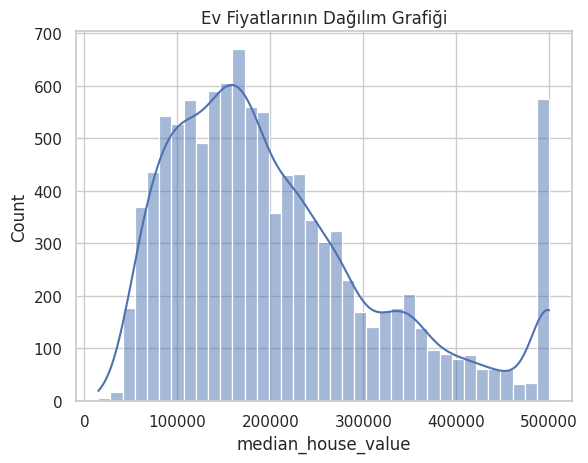

In [23]:
#Ev fiyatlarının dağılımına bakalım(Hedef Değişkenimiz)
sns.histplot(egitim['median_house_value'], kde=True)
plt.title('Ev Fiyatlarının Dağılım Grafiği')
plt.show()

/tmp/ipykernel_950/2891475780.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=egitim['median_house_value'], palette="Set2", width=0.5)


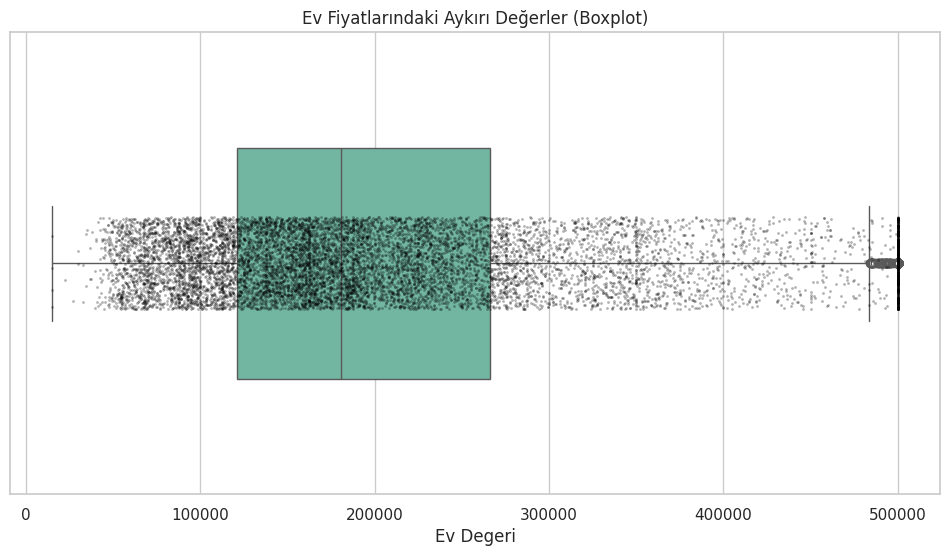

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
#Ev fiyatlarındaki aykırı değerleri görelim
plt.figure(figsize=(12, 6))
#Kutuyu çizip renk paletini ayarlıyoruz
sns.boxplot(x=egitim['median_house_value'], palette="Set2", width=0.5)
#Gercek erilerin yogunlugunu stripplot ile ekliyoruz
sns.stripplot(x=egitim['median_house_value'], color='black', size=2, alpha=0.3)
plt.title('Ev Fiyatlarındaki Aykırı Değerler (Boxplot)')
plt.xlabel('Ev Degeri')
plt.show()

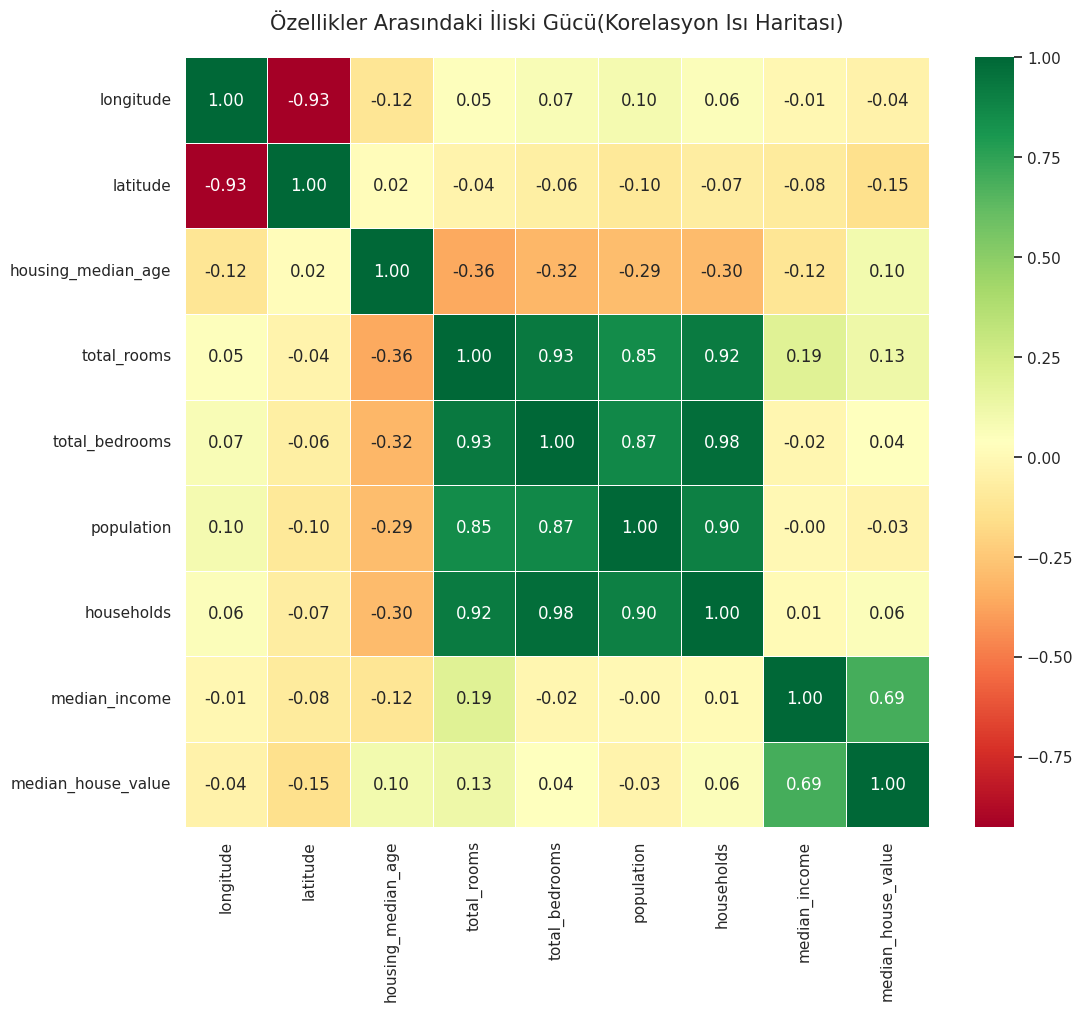

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
#Grafik boyutunu ayarlıyoruz
plt.figure(figsize=(12, 10))
#Korelasyon matrisini hesaplıyoruz
korelasyon_matrisi = egitim.corr()
#Isı haritasını ciziyoruz
#annot=True:Karelerin icine sayilari yazar
#cmap='RdYlGn':Kırmızıdan (negatif) Yesile(pozitif) renk skalası
#ftm='.2f':Virgülden sonra 2 basamak gösterir
sns.heatmap(korelasyon_matrisi,annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Özellikler Arasındaki İliski Gücü(Korelasyon Isı Haritası)', fontsize=15, pad=20)
plt.show()

In [26]:
from scipy import stats
#Sadece Sayisal sütunları seciyoruz
sayisal_sutunlar = egitim.select_dtypes(include=[np.number]).columns
#Z-Score Hesaplıyoruz
z_skorlari = np.abs(stats.zscore(egitim[sayisal_sutunlar]))
#Z-Score 3'ten büyük olanları (uç noktaları) veriden atıyoruz
egitim_temiz=egitim[(z_skorlari < 3).all(axis=1)]
print(f"Temizlikten önceki veri sayısı:{len(egitim)}")
print(f"Temizlikten sonraki veri sayısı:{len(egitim_temiz)}")
print("Aykırı değerler temizlendi")

Temizlikten önceki veri sayısı:10710
Temizlikten sonraki veri sayısı:10219
Aykırı değerler temizlendi


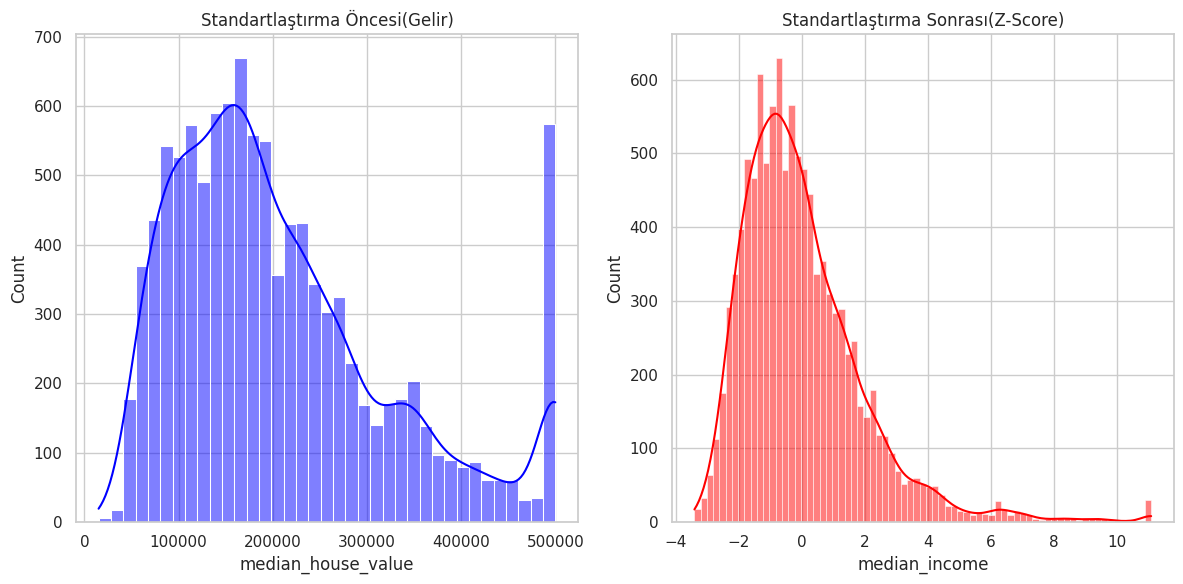

In [27]:
plt.figure(figsize=(12, 6))
#1.Grafik:Ham Veri(Büyük Sayilar)
plt.subplot(1, 2, 1)
sns.histplot(egitim['median_house_value'], kde=True, color='blue')
plt.title('Standartlaştırma Öncesi(Gelir)')
#2.Grafik:Standartlaştırılmış Veri(0 Tarafında Toplanmış)
standart_gelir=egitim['median_income'] - egitim['median_income'].mean()
plt.subplot(1, 2, 2)
sns.histplot(standart_gelir, kde=True, color='red')
plt.title('Standartlaştırma Sonrası(Z-Score)')
plt.tight_layout()
plt.show()


## 1. Veri Hazırlama ve Ön İşleme
Yapay sinir ağlarının başarısı, verilerin aynı ölçekte olmasına bağlıdır. Bu aşamada:
* **StandardScaler** kullanılarak veriler normalize edilmiş; böylece modelin her özelliğe eşit ağırlık vermesi sağlanmıştır.
* Aykırı değerler (outliers) görselleştirilerek veri setinin genel dağılımı incelenmiştir.

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
#1.Giriş(X) VE Çıkış (Y) Verilerini Ayırıyoruz
#Hedefimiz 'median_house_value'(ev fiyatı) tahmin etmek
X_train = egitim.drop('median_house_value', axis=1)
y_train = egitim['median_house_value']

X_test = test.drop('median_house_value', axis=1)
y_test = test['median_house_value']

#2.Standartlaşmayı (Z-Score Verilere Uyguluyoruz)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## 2. Model Mimarisinin Oluşturulması (MLP)
Modelimiz, regresyon problemlerinde yüksek performans gösteren derin bir mimari ile optimize edilmiştir:
* **Katman Yapısı:** 128, 64, 32 ve 16 nöronluk kademeli gizli katmanlar kullanılmıştır.
* **Dropout (%20):** Modelin eğitim verisini ezberlemesini (Overfitting) önlemek amacıyla bu katman eklenmiştir.
* **Optimizasyon:** Hızlı ve güvenilir yakınsama sağlayan `Adam` algoritması tercih edilmiştir.
* **Metrikler:** Başarıyı takip etmek için MSE, MAE ve MAPE metrikleri kullanılmıştır.

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

#Modeli Kuruyoruz
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    #Giriş Katmanı ve İlk Gizli Katman(Örn:64 nöron)
    Dense(64, activation='relu'),
    #İkinci Gizli Katman(Örn:32 nöron)
    Dense(32, activation='relu'),
    #Üçüncü Gizli Katman(Örn:16 nöron)
    Dense(16, activation='relu'),
    #Çıkış Katmanı(Örn:1 nöron, çünkü tek bir fiyat tahmin ediyoruz)
    Dense(1)
])
#Modeli derliyoruz Learning Rate ve Momentumun yazıldığı kısım
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mape'])
#Modelin özetini(Mimarisini ekrana yazdıran kısım)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#Durdurma kriterini ekliyoruz(Hata azalmazsa eğitimi kesicek)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
#Egitimi başlatıyoruz
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],#Durma kriterini aktif ediyor
    verbose=1
)



Epoch 1/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 55447781376.0000 - mae: 204758.7969 - mape: 97.9370 - val_loss: 18606766080.0000 - val_mae: 101846.1406 - val_mape: 45.4371
Epoch 2/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 14556316672.0000 - mae: 87708.5234 - mape: 46.6519 - val_loss: 8565666816.0000 - val_mae: 67861.5703 - val_mape: 38.9858
Epoch 3/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9344644096.0000 - mae: 68980.8906 - mape: 40.1706 - val_loss: 6828005888.0000 - val_mae: 59924.7656 - val_mape: 34.9157
Epoch 4/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7521836032.0000 - mae: 61983.8359 - mape: 36.0254 - val_loss: 5847644672.0000 - val_mae: 55575.4844 - val_mape: 32.5944
Epoch 5/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 6031684608.0000 - mae: 56894.8828 - mape: 33.9550 - val_loss: 5253276672.0000 - val_mae: 53080.3906 - val_mape: 31.2944
Epoch 6/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5534541312.0000 - mae: 54371.

## 3. Eğitim Süreci ve Öğrenme Eğrisi Analizi
Modelin eğitim süreci boyunca hatanın nasıl düştüğü grafikleştirilmiştir. Eğitim (Train) ve Doğrulama (Validation) kayıplarının paralel şekilde azalması, modelin sağlıklı bir öğrenme gerçekleştirdiğini ve kararlı olduğunu göstermektedir.

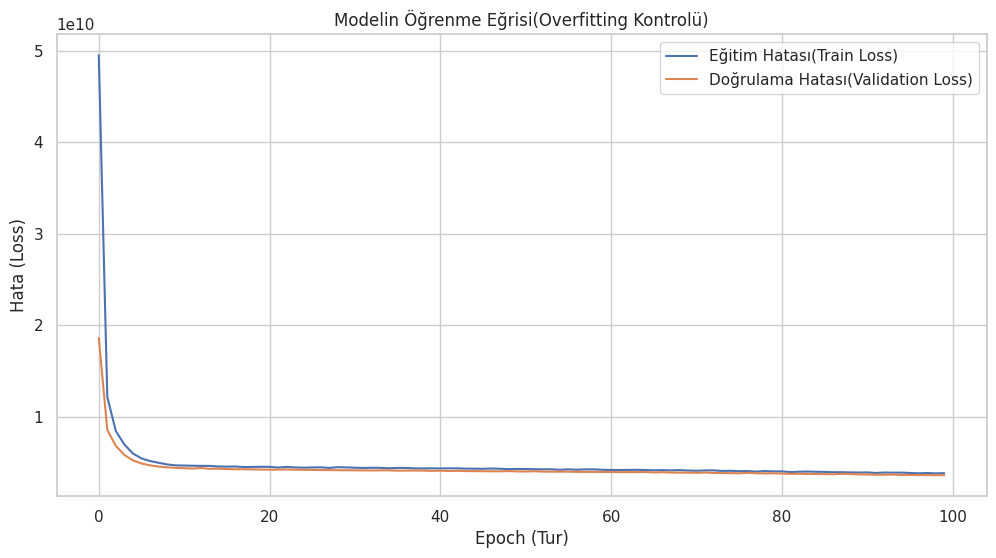

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Eğitim Hatası(Train Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Hatası(Validation Loss)')
plt.title('Modelin Öğrenme Eğrisi(Overfitting Kontrolü)')
plt.xlabel('Epoch (Tur)')
plt.ylabel('Hata (Loss)')
plt.legend()
plt.show()

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


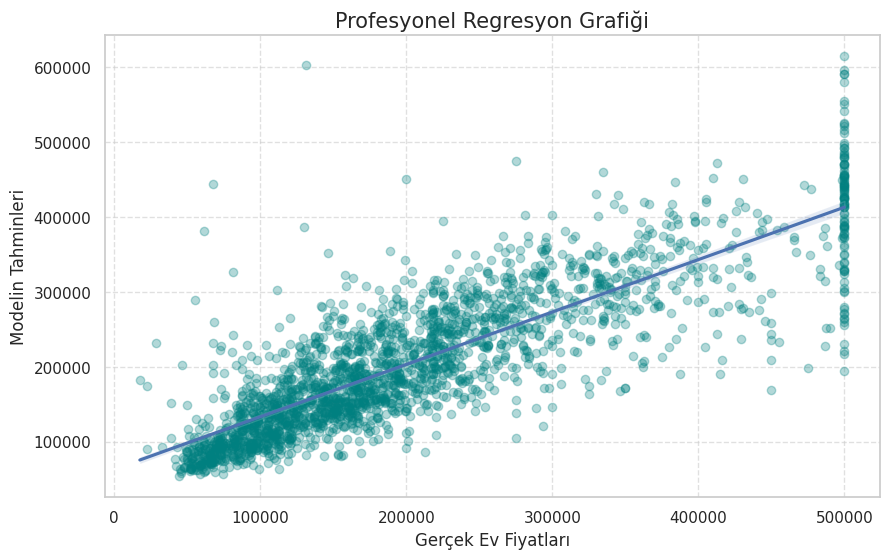

In [32]:
#Test Setindeki Tahminleri Yapıyoruz
y_pred = model.predict(X_test_scaled).flatten()
plt.figure(figsize=(10, 6))
#Hem dağılımı hem de regresyon çizgisini tek seferde çizer
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha' :0.3, 'color':'teal'})
plt.title('Profesyonel Regresyon Grafiği', fontsize=15)
plt.xlabel('Gerçek Ev Fiyatları', fontsize=12)
plt.ylabel('Modelin Tahminleri', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score
#Metrikleri Hesapla
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"--- Model Performansı Metrikleri ---")
print(f"R2 Skoru (Başarı Oranı):{r2:.4f}")
print(f"Ortalama Mutlak Hata (MAE):{mae:.2f}")
print(f"Kök Ortalama Karesel Hata (RMSE):{rmse:.2f}")

--- Model Performansı Metrikleri ---
R2 Skoru (Başarı Oranı):0.7009
Ortalama Mutlak Hata (MAE):43759.93
Kök Ortalama Karesel Hata (RMSE):62647.19


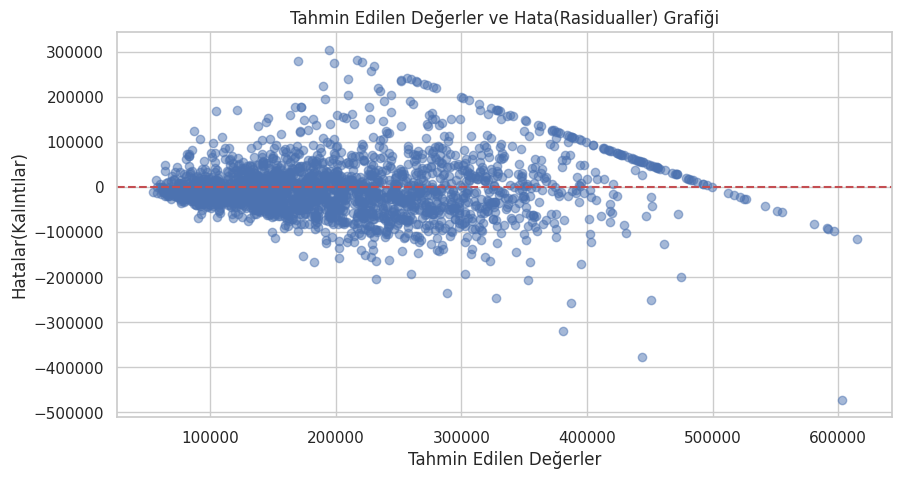

In [34]:
hatalar = y_test.values.flatten() - y_pred.flatten()
plt.figure(figsize=(10,5))
plt.scatter(y_pred, hatalar, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Tahmin Edilen Değerler')
plt.ylabel('Hatalar(Kalıntılar)')
plt.title('Tahmin Edilen Değerler ve Hata(Rasidualler) Grafiği')
plt.show()



In [35]:
#Hiç dokunmadığımız o %10'u hazırlayalım
X_final = final_test_verisi.drop('median_house_value', axis=1)
y_final = final_test_verisi['median_house_value']
#Eğittimiz ölçekleyici ile dönüştür
X_final_scaled = scaler.transform(X_final)
#Tahmin et ve sonucu gör
final_skor = r2_score(y_final, model.predict(X_final_scaled))
print(f"VE FİNAL SONUCU! Modelin hiç görmediği verideki başarısı:{final_skor:.4f}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
VE FİNAL SONUCU! Modelin hiç görmediği verideki başarısı:0.7237


## Sonuç

Modelin başarısı için geniş kapsamlı bir değerlendirme yapılmıştır:
* **R2 Skoru:** Modelin verideki değişkenliği açıklama oranını gösterir.
* **Regresyon Grafiği:** Tahminlerin gerçek fiyatlara ne kadar yakın olduğunu görsel olarak ispatlar.
* **Sonuç:** Yaklaşık %73 oranındaki R2 skoru, bu veri seti ve mimari için başarılı bir sonuçtur.